In [97]:
# # Data Handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("Corrected_Warehouse_Shift.xlsx")

In [98]:
df


,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Order_delay,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Sales_Per_Employee,Required_Employees,Employee_Gap,Total_Cost,profit,Inventory_Gap,Optimized_Stock
0,WH298,New York,4418,3948,6,4,10,6,74065,S355,Automotive,6836,4.43,8.3,4.0,43351,11037,7760,112,7,83,82.361446,40,-43,18797,102777.550549,-470,4418
1,WH414,Chicago,4473,2730,5,3,8,21,32188,S557,Groceries,3435,4.71,1.4,2.1,17183,2226,9199,87,14,17,202.058824,20,3,11425,49664.611050,-1743,4473
2,WH042,Chicago,2279,1930,4,3,7,24,72812,S569,Automotive,4016,3.27,3.6,1.0,46299,6101,12458,163,30,51,78.745098,24,-27,18559,52863.380779,-349,2279
3,WH322,Chicago,1502,2782,5,4,9,11,39104,S134,Furniture,1245,3.86,7.8,3.6,44913,12304,1408,81,15,79,15.759494,7,-72,13712,8429.649420,1280,2782
4,WH092,Miami,1330,1433,3,2,5,15,57086,S138,Furniture,2447,4.36,0.9,2.7,41005,7917,13814,255,13,95,25.757895,14,-81,21731,21787.567173,103,1433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH304(2),Los Angeles,1603,1993,1,1,2,14,62347,S103,Apparel,4964,1.24,4.6,3.4,42992,4735,14388,264,17,22,263.923077,20,7,19123,41895.473220,4011,5141
496,WH239(1),Chicago,305,592,2,1,2,22,43540,S120,Automotive,3933,4.75,2.5,4.9,29570,17196,717,141,7,21,191.829268,46,5,17913,121961.757178,573,1183
497,WH242(2),Atlanta,1505,882,1,0,1,15,71855,S646,Apparel,3878,1.82,8.6,3.0,42413,12091,7749,289,5,23,33.612245,19,-79,19840,38742.002561,505,3115
498,WH093(2),Dallas,2112,1798,1,0,1,16,84542,S315,Groceries,4100,2.73,8.1,3.9,14643,4303,5330,91,11,37,225.705882,22,5,9633,58605.962911,538,3448


In [99]:
df.shape

(500, 28)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Warehouse_ID           500 non-null    object 
 1   Location               500 non-null    object 
 2   Current_Stock          500 non-null    int64  
 3   Demand_Forecast        500 non-null    int64  
 4   Lead_Time_Days         500 non-null    int64  
 5   Shipping_Time_Days     500 non-null    int64  
 6   Order_delay            500 non-null    int64  
 7   Stockout_Risk          500 non-null    int64  
 8   Operational_Cost       500 non-null    int64  
 9   Supplier_ID            500 non-null    object 
 10  Product_Category       500 non-null    object 
 11  Monthly_Sales          500 non-null    int64  
 12  Order_Processing_Time  500 non-null    float64
 13  Return_Rate            500 non-null    float64
 14  Customer_Rating        500 non-null    float64
 15  Wareho

In [101]:
pd.set_option('display.max_columns', None)

In [102]:
# Top 20 warehouse   where highest monthly sales basis of employee count
warehouse_summary = (
    df.groupby('Warehouse_ID')
    .agg({
        'Monthly_Sales': 'sum',
        'Employee_Count': 'sum'
    })
).sort_values(
        by='Monthly_Sales',
        ascending=False
    ).head(20)
warehouse_summary

,Monthly_Sales,Employee_Count
Warehouse_ID,,
WH039,22394,157
WH125,18281,173
WH033(2),17911,92
WH033(1),17911,94
WH162,15614,196
WH195,15279,163
WH488,14001,206
WH254,13756,77
WH007,13539,142


In [103]:
# Average Monthly Sales of Top 20 Warehouses
avg_monthly_sales = warehouse_summary['Monthly_Sales'].mean()

# Average Employee Count of Top 20 Warehouses
avg_employee_count = warehouse_summary['Employee_Count'].mean()

print("Average Monthly Sales:", round(avg_monthly_sales, 2))
print("Average Employee Count:", round(avg_employee_count, 2))

Average Monthly Sales: 14511.3
Average Employee Count: 128.1


In [104]:
# create Per employee average value basis of top 20 warehouse average of monthly sales and average of employee count

Avg_one_emp_sales = (14511/128)
Avg_one_emp_sales

113.3671875

In [105]:
# create Required employee column
df["Required_Employees"] = (
    df["Monthly_Sales"] / Avg_one_emp_sales
).round().astype(int)

In [106]:
# Top 20 warehouse where where Lowest monthly sales basis of employee count
warehouse_summary = (
    df.groupby('Warehouse_ID')
    .agg({
        'Monthly_Sales': 'sum',
        'Employee_Count': 'sum',
        'Required_Employees':'sum'
    })
).sort_values(
        by='Monthly_Sales',
        ascending=True
    ).head(50)
warehouse_summary

,Monthly_Sales,Employee_Count,Required_Employees
Warehouse_ID,,,
WH205,1150,57,10
WH302,1220,69,11
WH190,1225,59,11
WH322,1245,79,11
WH078,1248,46,11
WH391,1288,51,11
WH499,1314,87,12
WH253,1392,7,12
WH050,1393,89,12


In [107]:
# create employee gap column (check how many employee want in which warehouse and how many employee you want to remove)
df["Employee_Gap"] = (
    df["Required_Employees"]
    - df["Employee_Count"]
)

In [108]:
# in all these warehouse extra staff
extra_staff = (df[df["Employee_Gap"] < 0])
extra_staff

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Order_delay,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Sales_Per_Employee,Required_Employees,Employee_Gap,Total_Cost,profit,Inventory_Gap,Optimized_Stock
0,WH298,New York,4418,3948,6,4,10,6,74065,S355,Automotive,6836,4.43,8.3,4.0,43351,11037,7760,112,7,83,82.361446,60,-23,18797,102777.550549,-470,4418
2,WH042,Chicago,2279,1930,4,3,7,24,72812,S569,Automotive,4016,3.27,3.6,1.0,46299,6101,12458,163,30,51,78.745098,35,-16,18559,52863.380779,-349,2279
3,WH322,Chicago,1502,2782,5,4,9,11,39104,S134,Furniture,1245,3.86,7.8,3.6,44913,12304,1408,81,15,79,15.759494,11,-68,13712,8429.649420,1280,2782
4,WH092,Miami,1330,1433,3,2,5,15,57086,S138,Furniture,2447,4.36,0.9,2.7,41005,7917,13814,255,13,95,25.757895,22,-73,21731,21787.567173,103,1433
5,WH099,Miami,4998,1200,4,3,7,16,64791,S411,Furniture,6075,0.76,5.7,3.9,35815,2792,11106,256,47,78,77.884615,54,-24,13898,94142.578494,-3798,4998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,WH093(1),Dallas,2112,1798,1,1,2,22,63818,S867,Apparel,4100,2.37,5.3,2.6,24435,10588,8540,297,36,38,109.333333,36,-2,19128,126704.550395,-628,4224
491,WH287(2),Atlanta,2346,2153,2,0,2,6,55459,S157,Automotive,4941,3.55,3.4,4.4,36306,2942,3679,179,43,48,22.937500,44,-4,6621,12959.687559,277,5137
492,WH354(1),Atlanta,1507,1387,1,1,2,14,68302,S306,Furniture,4442,2.38,7.6,5.0,15190,13477,8696,255,7,47,94.500000,39,-8,22173,135806.334776,-239,3013
498,WH093(2),Dallas,2112,1798,1,0,1,16,84542,S315,Groceries,4100,2.73,8.1,3.9,14643,4303,5330,91,11,37,225.705882,36,-1,9633,58605.962911,538,3448


In [109]:
# in this all warehouse need staff
needed_staff = df[df["Employee_Gap"] > 0]
needed_staff

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Order_delay,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Sales_Per_Employee,Required_Employees,Employee_Gap,Total_Cost,profit,Inventory_Gap,Optimized_Stock
1,WH414,Chicago,4473,2730,5,3,8,21,32188,S557,Groceries,3435,4.71,1.4,2.1,17183,2226,9199,87,14,17,202.058824,30,13,11425,49664.611050,-1743,4473
6,WH153,Atlanta,3630,956,2,4,6,7,45897,S517,Apparel,3023,2.74,5.3,2.6,16306,10185,14293,96,41,25,120.920000,27,2,24478,29284.414615,-2674,3630
13,WH466,Atlanta,4416,2857,2,3,5,6,45999,S310,Groceries,5491,3.55,3.7,2.9,21769,16669,2443,87,10,11,499.181818,48,37,19112,78542.455393,-1559,4416
16,WH077,Miami,4930,1596,4,2,6,16,65180,S999,Apparel,5159,3.02,1.2,4.7,18352,11701,13753,293,30,35,147.400000,46,11,25454,66296.015548,-3334,4930
25,WH199,Atlanta,2677,3594,6,3,9,9,93093,S319,Electronics,7549,0.87,8.9,2.8,47231,8493,3125,201,9,16,471.812500,67,51,11618,122636.868651,917,3594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,WH209(2),Denver,1664,1513,1,1,2,11,81104,S775,Electronics,3841,1.55,6.5,1.8,38384,18938,11559,57,38,6,29.500000,34,28,30497,-8462.057324,-456,3512
494,WH097(2),Houston,2294,2088,1,1,2,24,64485,S742,Furniture,4881,3.99,4.6,3.5,48768,16192,9028,199,32,13,164.250000,43,30,25220,33201.942445,3628,5004
495,WH304(2),Los Angeles,1603,1993,1,1,2,14,62347,S103,Apparel,4964,1.24,4.6,3.4,42992,4735,14388,264,17,22,263.923077,44,22,19123,41895.473220,4011,5141
496,WH239(1),Chicago,305,592,2,1,2,22,43540,S120,Automotive,3933,4.75,2.5,4.9,29570,17196,717,141,7,21,191.829268,35,14,17913,121961.757178,573,1183


In [110]:
# Total_emp
total_employee=df['Employee_Count'].sum()
total_employee

np.int64(20149)

In [111]:
# Required Emp
required=df['Required_Employees'].sum()
required

np.int64(20213)

In [112]:
# df["Need_Emp_Shifting"] = np.where(
#     df["Employee_Gap"] > 0,
#     df["Employee_Gap"],
#     0
# )

In [113]:
# df["Remove_Emp_Shifting"] = np.where(
#     df["Employee_Gap"] < 0,
#     abs(df["Employee_Gap"]),
#     0
# )

In [114]:
# total_need = df["Need_Emp_Shifting"].sum()
# total_extra = df["Remove_Emp_Shifting"].sum()

# employees_to_shift = min(total_need, total_extra)

In [115]:
# extra_emp = abs(df.loc[df["Employee_Gap"] < 0, "Employee_Gap"].sum())

# need_emp = df.loc[df["Employee_Gap"] > 0, "Employee_Gap"].sum()

# print("Extra Employees:", extra_emp)
# print("Employees Needed:", need_emp)

In [116]:
# # Create new column in this column find how many emp i want to shift
df['Need_Emp_Shifting'] = np.where(
    (df['Inventory_Gap'] > 0) & (df['Employee_Gap'] > 0),
    np.ceil(df['Inventory_Gap'] / Avg_one_emp_sales).astype(int),
    0
) 


In [117]:
# # # Shifting emp in required Emp Column
df["Required_Employees"]=df['Required_Employees']+df['Need_Emp_Shifting']

In [118]:
 # After Shifting emp Add Monthly Sales
df['Monthly_Sales']=df['Monthly_Sales']+(df['Need_Emp_Shifting']*Avg_one_emp_sales)

In [119]:
# Required Emp
required=df['Required_Employees'].sum()


In [120]:
#Emp_gap update after shifting Need Emp
df['Employee_Gap']=df["Required_Employees"]-df['Employee_Count']


In [121]:
# # find cost per employees
df['Cost_Per_Sale'] = (
    df['Operational_Cost'] /
    df['Monthly_Sales']
)

In [122]:
avg_cost_per_sale=df['Cost_Per_Sale'].mean()
avg_cost_per_sale

np.float64(15.538806211904678)

In [123]:
df['Revenue']=df['Monthly_Sales']*avg_cost_per_sale

In [124]:
# storage charge and  Transpotation Charge
df['Total_Cost']=df['Storage_Cost']+df['Transportation_Cost']

In [125]:
df['profit']=df['Revenue']-df['Total_Cost']
df['profit']

0       87426.279265
1       41950.799338
2       43844.845747
3        5633.813734
4       16292.458801
           ...      
495    121428.901301
496     53770.669376
497     49227.444277
498     54076.105469
499     53587.838387
Name: profit, Length: 500, dtype: float64

In [126]:
profit=df['profit']>0
profit.sum()

np.int64(491)

In [127]:
# create new column for checking demand
df['Inventory_Gap'] = (
    df['Demand_Forecast'] -
    df['Current_Stock']
)

In [128]:
df['Optimized_Stock'] = np.where(
    df['Inventory_Gap'] > 0,
    df['Demand_Forecast'],
    df['Current_Stock']
)

In [129]:
# Chek order delay
df['Order_delay']=df['Lead_Time_Days']+df['Shipping_Time_Days']

In [130]:
# top 20 delay warehouse basis of order delay
Delay_Summary = (
    df.groupby(['Warehouse_ID','Location'])
    .agg({
        'Monthly_Sales': 'sum',
        'Employee_Count': 'sum',
        'Required_Employees':'sum',
        'Order_delay':'sum'
    })
).sort_values(
        by='Order_delay',
        ascending=False
    ).head(20)
Delay_Summary

,,Monthly_Sales,Employee_Count,Required_Employees,Order_delay
Warehouse_ID,Location,,,,
WH257,Houston,11274.000000,164,99,20
WH080,Seattle,7426.000000,133,66,17
WH124,New York,14766.507812,97,130,17
WH162,Chicago,12287.000000,158,108,15
WH039,New York,9829.367188,39,87,15
WH500,Dallas,5015.000000,14,44,12
WH013,Miami,2027.000000,35,18,12
WH254,Dallas,6759.000000,23,60,12
WH055,Dallas,3819.000000,31,34,12


In [131]:
df.head(120)

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Order_delay,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Sales_Per_Employee,Required_Employees,Employee_Gap,Total_Cost,profit,Inventory_Gap,Optimized_Stock,Need_Emp_Shifting,Cost_Per_Sale,Revenue
0,WH298,New York,4418,3948,6,4,10,6,74065,S355,Automotive,6836.000000,4.43,8.3,4.0,43351,11037,7760,112,7,83,82.361446,60,-23,18797,87426.279265,-470,4418,0,10.834552,106223.279265
1,WH414,Chicago,4473,2730,5,3,8,21,32188,S557,Groceries,3435.000000,4.71,1.4,2.1,17183,2226,9199,87,14,17,202.058824,30,13,11425,41950.799338,-1743,4473,0,9.370597,53375.799338
2,WH042,Chicago,2279,1930,4,3,7,24,72812,S569,Automotive,4016.000000,3.27,3.6,1.0,46299,6101,12458,163,30,51,78.745098,35,-16,18559,43844.845747,-349,2279,0,18.130478,62403.845747
3,WH322,Chicago,1502,2782,5,4,9,11,39104,S134,Furniture,1245.000000,3.86,7.8,3.6,44913,12304,1408,81,15,79,15.759494,11,-68,13712,5633.813734,1280,2782,0,31.408835,19345.813734
4,WH092,Miami,1330,1433,3,2,5,15,57086,S138,Furniture,2447.000000,4.36,0.9,2.7,41005,7917,13814,255,13,95,25.757895,22,-73,21731,16292.458801,103,1433,0,23.328974,38023.458801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,WH082,Dallas,3756,1623,8,2,10,25,83069,S801,Apparel,4363.000000,4.84,6.3,2.3,48455,5138,12163,276,43,18,242.388889,38,20,17301,50494.811503,-2133,3756,0,19.039422,67795.811503
116,WH287,Dallas,3298,408,7,3,10,9,32024,S971,Groceries,6968.000000,2.76,7.9,3.3,10604,5177,10228,149,30,19,366.736842,61,42,15405,92869.401685,-2890,3298,0,4.595867,108274.401685
117,WH092(1),San Francisco,1774,2559,2,3,5,20,46592,S799,Electronics,6286.140625,2.69,5.0,2.9,11927,1357,9805,184,40,39,120.487179,55,16,11162,86517.120993,785,2559,14,7.411861,97679.120993
118,WH358,Houston,1336,2299,3,7,10,16,58287,S207,Automotive,6728.000000,0.86,4.7,3.3,41200,3103,9223,270,5,65,103.507692,59,-6,12326,92219.088194,963,2299,0,8.663347,104545.088194


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Warehouse_ID           500 non-null    object 
 1   Location               500 non-null    object 
 2   Current_Stock          500 non-null    int64  
 3   Demand_Forecast        500 non-null    int64  
 4   Lead_Time_Days         500 non-null    int64  
 5   Shipping_Time_Days     500 non-null    int64  
 6   Order_delay            500 non-null    int64  
 7   Stockout_Risk          500 non-null    int64  
 8   Operational_Cost       500 non-null    int64  
 9   Supplier_ID            500 non-null    object 
 10  Product_Category       500 non-null    object 
 11  Monthly_Sales          500 non-null    float64
 12  Order_Processing_Time  500 non-null    float64
 13  Return_Rate            500 non-null    float64
 14  Customer_Rating        500 non-null    float64
 15  Wareho

In [133]:
print("Average Monthly Sales:", df['Revenue'].mean())
print("Average Total Cost:", df['Total_Cost'].mean())
print("Average Profit:", df['profit'].mean())

Average Monthly Sales: 80357.9517958152
Average Total Cost: 18232.92
Average Profit: 62125.031795815215


In [134]:
# Total Sales by Product Category

product_sales = df.groupby(
    'Product_Category'
)['Monthly_Sales'].mean()

print(product_sales)

Product_Category
Apparel        5106.721239
Automotive     5053.662219
Electronics    5339.715625
Furniture      5220.731267
Groceries      5136.983929
Name: Monthly_Sales, dtype: float64


In [135]:
# Total product stock by Product Category
product_Stock= df.groupby(
    'Product_Category'
)['Current_Stock'].sum()

print(product_Stock)

Product_Category
Apparel        234038
Automotive     179970
Electronics    202421
Furniture      200028
Groceries      234247
Name: Current_Stock, dtype: int64


In [136]:
# Average Customer Rating by Product Category

rating_by_category = df.groupby(
    'Product_Category'
)['Customer_Rating'].mean()
print(rating_by_category)

Product_Category
Apparel        3.025664
Automotive     3.178652
Electronics    3.209000
Furniture      3.082796
Groceries      2.980000
Name: Customer_Rating, dtype: float64


In [137]:
df

,Warehouse_ID,Location,Current_Stock,Demand_Forecast,Lead_Time_Days,Shipping_Time_Days,Order_delay,Stockout_Risk,Operational_Cost,Supplier_ID,Product_Category,Monthly_Sales,Order_Processing_Time,Return_Rate,Customer_Rating,Warehouse_Capacity,Storage_Cost,Transportation_Cost,Backorder_Quantity,Damaged_Goods,Employee_Count,Sales_Per_Employee,Required_Employees,Employee_Gap,Total_Cost,profit,Inventory_Gap,Optimized_Stock,Need_Emp_Shifting,Cost_Per_Sale,Revenue
0,WH298,New York,4418,3948,6,4,10,6,74065,S355,Automotive,6836.000000,4.43,8.3,4.0,43351,11037,7760,112,7,83,82.361446,60,-23,18797,87426.279265,-470,4418,0,10.834552,106223.279265
1,WH414,Chicago,4473,2730,5,3,8,21,32188,S557,Groceries,3435.000000,4.71,1.4,2.1,17183,2226,9199,87,14,17,202.058824,30,13,11425,41950.799338,-1743,4473,0,9.370597,53375.799338
2,WH042,Chicago,2279,1930,4,3,7,24,72812,S569,Automotive,4016.000000,3.27,3.6,1.0,46299,6101,12458,163,30,51,78.745098,35,-16,18559,43844.845747,-349,2279,0,18.130478,62403.845747
3,WH322,Chicago,1502,2782,5,4,9,11,39104,S134,Furniture,1245.000000,3.86,7.8,3.6,44913,12304,1408,81,15,79,15.759494,11,-68,13712,5633.813734,1280,2782,0,31.408835,19345.813734
4,WH092,Miami,1330,1433,3,2,5,15,57086,S138,Furniture,2447.000000,4.36,0.9,2.7,41005,7917,13814,255,13,95,25.757895,22,-73,21731,16292.458801,103,1433,0,23.328974,38023.458801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,WH304(2),Los Angeles,1603,1993,1,1,2,14,62347,S103,Apparel,9045.218750,1.24,4.6,3.4,42992,4735,14388,264,17,22,263.923077,80,58,19123,121428.901301,390,1993,36,6.892813,140551.901301
496,WH239(1),Chicago,305,592,2,1,3,22,43540,S120,Automotive,4613.203125,4.75,2.5,4.9,29570,17196,717,141,7,21,191.829268,41,20,17913,53770.669376,287,592,6,9.438128,71683.669376
497,WH242(2),Atlanta,1505,882,1,0,1,15,71855,S646,Apparel,4444.835938,1.82,8.6,3.0,42413,12091,7749,289,5,23,33.612245,39,16,19840,49227.444277,-623,1505,5,16.165951,69067.444277
498,WH093(2),Dallas,2112,1798,1,0,1,16,84542,S315,Groceries,4100.000000,2.73,8.1,3.9,14643,4303,5330,91,11,37,225.705882,36,-1,9633,54076.105469,-314,2112,0,20.620000,63709.105469


# Visualization

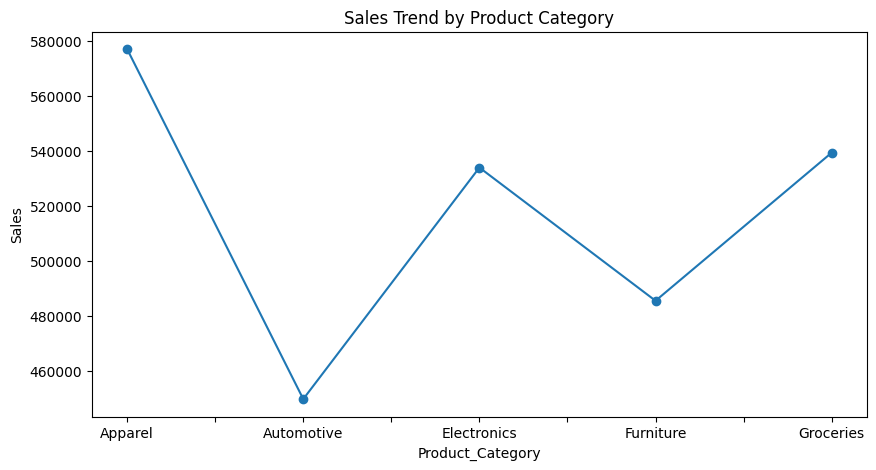

In [138]:
sales_trend = df.groupby(
    'Product_Category'
)['Monthly_Sales'].sum()

sales_trend.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Sales Trend by Product Category")
plt.ylabel("Sales")
plt.show()

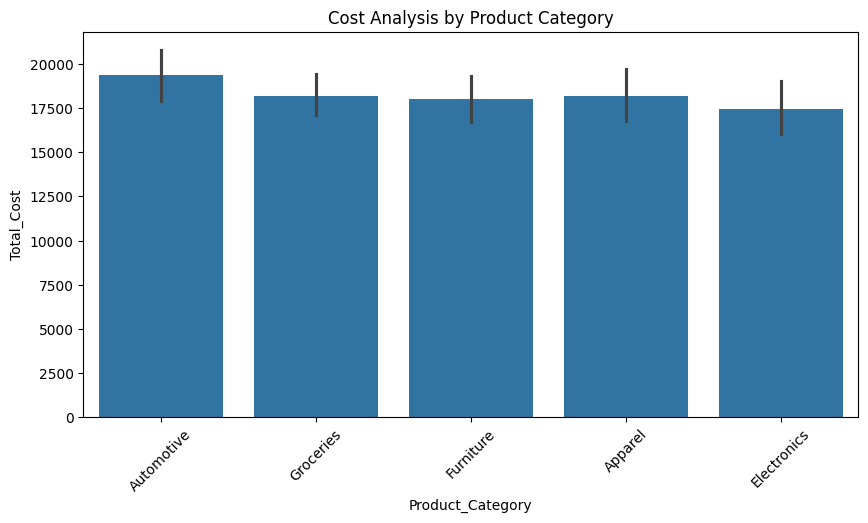

In [139]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Product_Category',
    y='Total_Cost',
    data=df
)

plt.xticks(rotation=45)

plt.title("Cost Analysis by Product Category")
plt.show()

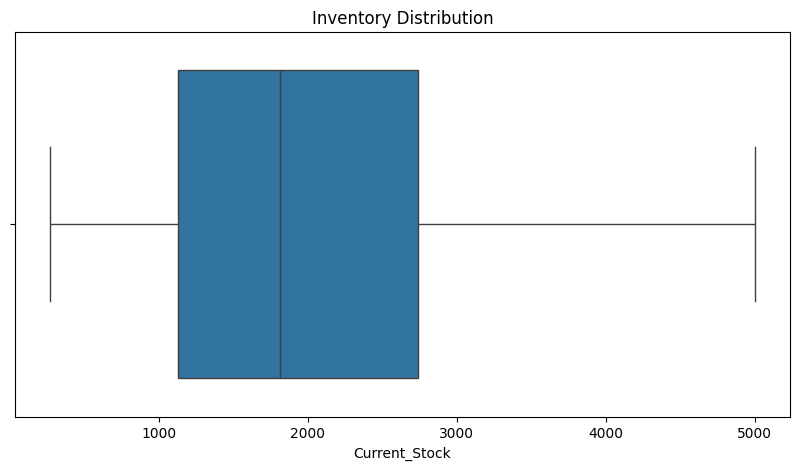

In [140]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Current_Stock']
)

plt.title("Inventory Distribution")
plt.show()

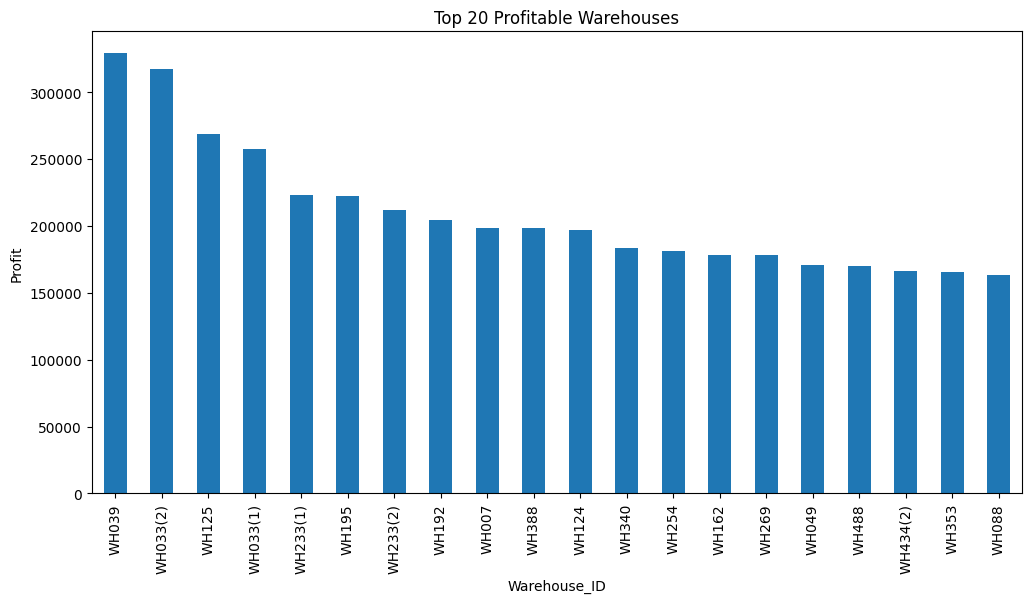

In [141]:
# Top 20 Warehouse profit
warehouse_profit = (
    df.groupby("Warehouse_ID")["profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
warehouse_profit.head(20).plot(kind="bar")
plt.title("Top 20 Profitable Warehouses")
plt.ylabel("Profit")
plt.show()

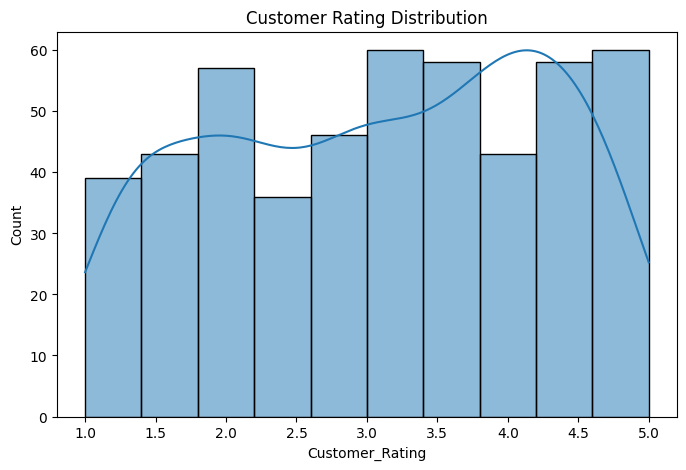

In [142]:
# Customer Rating Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Customer_Rating"],
    bins=10,
    kde=True
)

plt.title("Customer Rating Distribution")
plt.show()

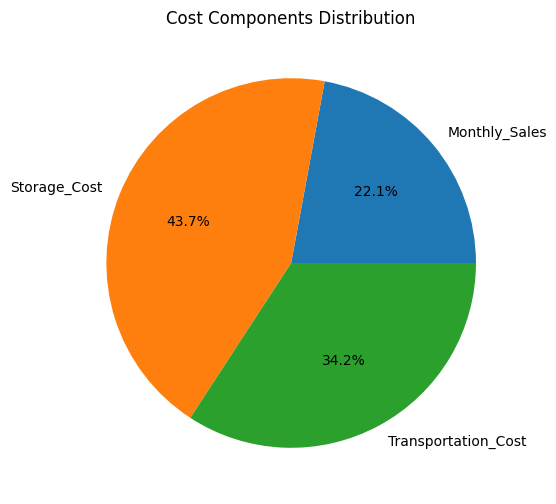

In [143]:
costs = df[[
    'Monthly_Sales',
    'Storage_Cost',
    'Transportation_Cost'
]].sum()

costs.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Cost Components Distribution")

plt.ylabel("")

plt.show()

In [144]:
df.to_excel(
    "Updated_File.xlsx",
    index=False)